4. Analyze a dataset recording daily study hours and sleep duration for students. Perform bivariate analysis
and create visualizations to investigate the relationship between study time and sleep duration.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("study_sleep_basic.csv")

In [3]:
df.head()

,study_hours,sleep_hours
0,2.0,7.0
1,4.0,6.0
2,6.0,5.0
3,3.0,8.0
4,8.0,4.0


In [4]:
#Basic info about the data
df.describe()

,study_hours,sleep_hours
count,25.000000,26.000000
mean,5.480000,6.192308
std,3.177001,2.800275
min,-1.000000,-2.000000
25%,3.000000,5.000000
50%,5.000000,6.000000
75%,7.000000,7.000000
max,13.000000,15.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  25 non-null     float64
 1   sleep_hours  26 non-null     float64
dtypes: float64(2)
memory usage: 564.0 bytes


In [6]:
print("Before Preprocessing")
print(f"Missing values in data{df.isnull().sum()}")
print(f"Duplicate Values in data: {df.duplicated().sum()}")

Before Preprocessing
Missing values in datastudy_hours    2
sleep_hours    1
dtype: int64
Duplicate Values in data: 4


In [7]:
#lets remove missing values and duplicates
df = df.dropna(subset=['study_hours','sleep_hours']).drop_duplicates()

In [8]:
print("After Preprocessing")
print(f"Missing values in data{df.isnull().sum()}")
print(f"Duplicate Values in data: {df.duplicated().sum()}")

After Preprocessing
Missing values in datastudy_hours    0
sleep_hours    0
dtype: int64
Duplicate Values in data: 0


In [9]:
#lets remove inconsistant values 
df = df[(df['study_hours']>0) & (df['study_hours']<=12)]
df = df[(df['sleep_hours']>0) & (df['sleep_hours']<=14)]

In [10]:
#statistics after preprocessing
print("Total_records: ",df.shape[0])
print(df.describe())
print("\nCorrelation between study_hours and sleep hours: ",df['study_hours'].corr(df['sleep_hours']).round(2))

Total_records:  17
       study_hours  sleep_hours
count    17.000000    17.000000
mean      5.764706     5.882353
std       2.727852     1.495090
min       2.000000     3.000000
25%       4.000000     5.000000
50%       5.000000     6.000000
75%       8.000000     7.000000
max      11.000000     8.000000

Correlation between study_hours and sleep hours:  -0.73


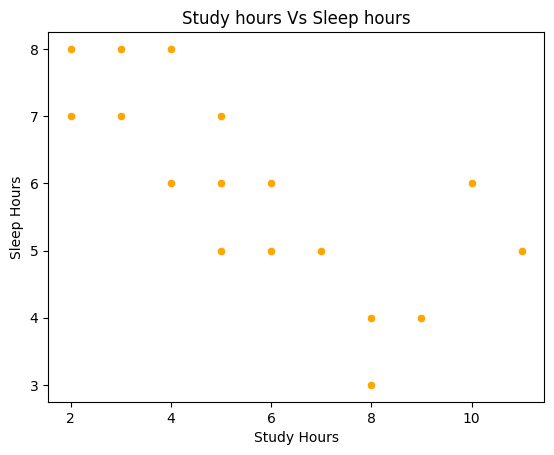

In [11]:
#bivariate analysis
sns.scatterplot(
    data=df,
    x='study_hours',
    y='sleep_hours',
    color="orange"
)
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Study hours Vs Sleep hours")
plt.show()

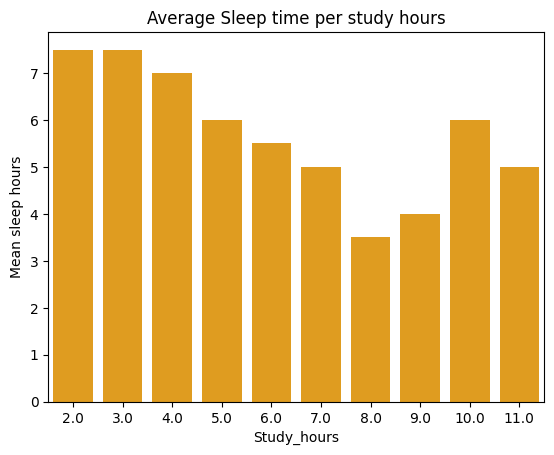

In [12]:
sleep_mean=df.groupby(df["study_hours"].round())["sleep_hours"].mean()
sns.barplot(
    sleep_mean,
    color='orange'
)
plt.xlabel("Study_hours")
plt.ylabel("Mean sleep hours")
plt.title("Average Sleep time per study hours")
plt.show()

In [15]:
# average sleep hour with respect to study hours
df.groupby(df["study_hours"].round())["sleep_hours"].mean()

study_hours
2.0     7.5
3.0     7.5
4.0     7.0
5.0     6.0
6.0     5.5
7.0     5.0
8.0     3.5
9.0     4.0
10.0    6.0
11.0    5.0
Name: sleep_hours, dtype: float64